
### Lab Introduction

The lab content for this course will consist of a number of lab exercises that are designed to familiarise you with the course content and prepare you for the summative assignments. Each of the labs will have a practical and theoretical component and all work should be completed in the notebook provided. The labs are designed to be run on the university vLab server however can be run locally provided you have set up the appropriate Python environments. 

### Lab 1

In this lab exercise, we will introduce the basics required for this module including image loading, output and manipulation. 

You will look at applying edge detectors to images and comparing two different methods. 

At this stage, we will assume that you are able to use Python, and understand its basic use. 

##### Introduction

First we will cover some basics regarding Python and Image Manipulation.

The first step is importing the required packages. In this assignment we will be using scikit-image, MatPlotLib and Numpy. We have also provided helper functions for displaying the images inline. Check that your environment is configured correctly by running the section below. If this section fails, refer to the README on how to set up the environment.

In [2]:
# Imports
import skimage
import scipy
from matplotlib import pyplot as plt
import numpy as np

In order to load images we use the imread function which is part of scikit-image. Images can be displayed using the show_rgb_image helper function. Read through this function to understand how it works. We can also see the raw image data by printing the variable using `print`. As can be seen, by default in Skimage image pixels are represented as bytes with a range of 0-255.

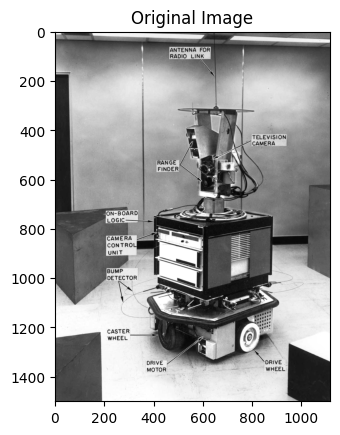

Shakey raw values [[254 254 254 ... 131 122 122]
 [254 254 254 ... 120 113 113]
 [254 254 254 ... 121 113 113]
 ...
 [ 83  81  78 ...  39  39  39]
 [ 83  81  78 ...  41  41  41]
 [ 83  81  78 ...  43  43  43]]


In [6]:
# Read image
shakey = skimage.io.imread('shakey.jpg')[:,:,0] #Extract the Green Channel

# Display the image
plt.imshow(shakey,cmap="gray")
plt.title("Original Image")
plt.axis('on')
plt.show()

print("Shakey raw values", shakey)

In scikit we perform convolution using the convolve2d function. Kernels can be defined as numpy arrays as seen below. A detailed guide to this function can be found here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html

In [8]:
sobel_x = np.array(
    [[1,0,-1],
     [2,0,-2],
     [1,0,-1]])

sobel_y = np.array(
    [[1,2,1],
     [0,0,0],
     [-1,-2,-1]])
print(sobel_x)
print(sobel_y)

[[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
[[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


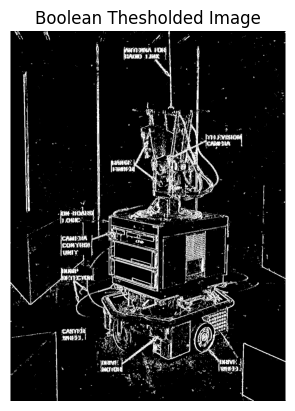

In [9]:
# Applying a filter
# We convert the output type to floats in order to preserve negative gradients
# We can also threshold the image using the > operator
threshold_shakey_sobel_x = abs(scipy.signal.convolve2d(shakey, sobel_x))>50

plt.imshow(threshold_shakey_sobel_x,cmap="gray")
plt.title("Boolean Thesholded Image")
plt.axis('off')
plt.show()

So far we have covered how to load images into Python, perform basic manipulation such as convolution and finally output images. The following tasks are designed to recap on content that has been covered in the Computer Vision module. Explore online documentation to implement the following tasks.

#### Task 1: Reimplement the the block above using OpenCV

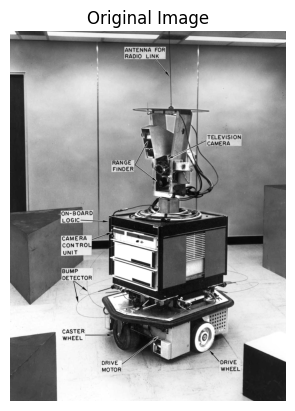

Shakey raw values:
 [[254 254 254 ... 131 122 122]
 [254 254 254 ... 120 113 113]
 [254 254 254 ... 121 113 113]
 ...
 [ 83  81  78 ...  39  39  39]
 [ 83  81  78 ...  41  41  41]
 [ 83  81  78 ...  43  43  43]]
Sobel X Kernel:
 [[ 1.  0. -1.]
 [ 2.  0. -2.]
 [ 1.  0. -1.]]
Sobel Y Kernel:
 [[ 1.  2.  1.]
 [ 0.  0.  0.]
 [-1. -2. -1.]]


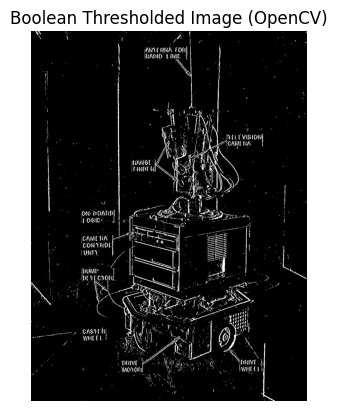

In [11]:
## Apply the filter using OpenCV
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Read image
shakey = cv2.imread('shakey.jpg')[:, :, 1]

# Display the image
plt.imshow(shakey, cmap="gray")
plt.title("Original Image")
plt.axis('off')
plt.show()

print("Shakey raw values:\n", shakey)

sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

sobel_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

print("Sobel X Kernel:\n", sobel_x)
print("Sobel Y Kernel:\n", sobel_y)

# convolutino
conv_x = cv2.filter2D(shakey, -1, sobel_x)

# Boolean Thresholding
threshold_shakey_sobel_x = np.abs(conv_x) > 50

# show
plt.imshow(threshold_shakey_sobel_x, cmap="gray")
plt.title("Boolean Thresholded Image (OpenCV)")
plt.axis('off')
plt.show()

#### Task 2: Apply Canny Edge Detection to the original shakey image using both OpenCV and Scipy

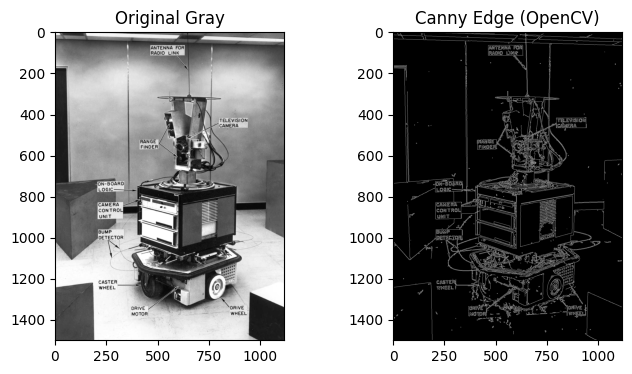

In [12]:
## Apply Canny Edge Detection OpenCV

img = cv2.imread('shakey.jpg', cv2.IMREAD_GRAYSCALE)

# Canny Edge Detection
# parameter：50 (low), 150 (high)
edges_cv2 = cv2.Canny(img, 50, 150)


plt.figure(figsize=(8, 4))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original Gray')
plt.subplot(122), plt.imshow(edges_cv2, cmap='gray'), plt.title('Canny Edge (OpenCV)')
plt.show()

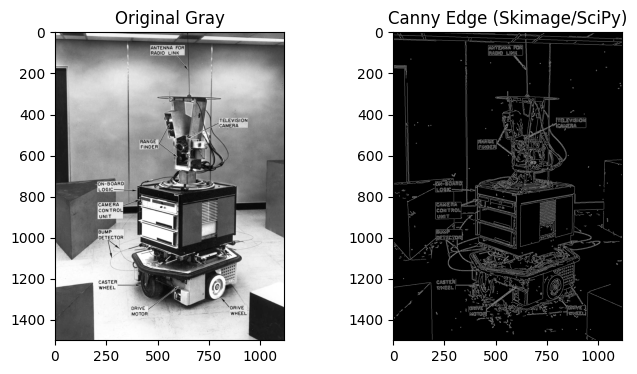

In [13]:
## Apply Canny Edge Detection Scipy
from skimage import feature, io
import matplotlib.pyplot as plt

# skimage loading image
shakey_gray = io.imread('shakey.jpg', as_gray=True)

# Canny
edges_scipy = feature.canny(shakey_gray, sigma=1.0)

plt.figure(figsize=(8, 4))
plt.subplot(121), plt.imshow(shakey_gray, cmap='gray'), plt.title('Original Gray')
plt.subplot(122), plt.imshow(edges_scipy, cmap='gray'), plt.title('Canny Edge (Skimage/SciPy)')
plt.show()

#### Task 3: Apply Straight line hough transform to the canny image using either OpenCV or Scipy 

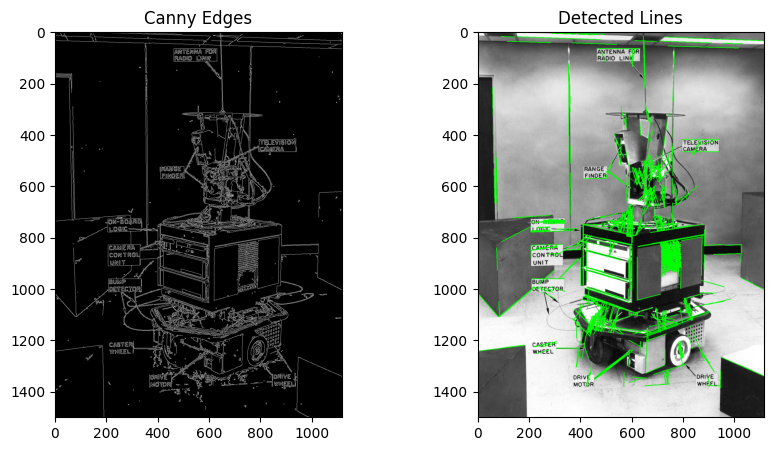

In [14]:
## Straight line hough transform
img = cv2.imread('shakey.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

# robabilistic Hough Transform
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, 
                        minLineLength=50, maxLineGap=10)

# 3. Draw the detected lines on the original image
line_img = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Canny Edges')
plt.subplot(122), plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB)), plt.title('Detected Lines')
plt.show()

# Questions

Since there has only been one week of teaching, these questions primarily pertain to content from the previous computer vision module. If you are not familiar with these topics, please research them online. Write 2-3 sentences per answer.

#### Why is Gaussian smoothing typically applied before detecting edges in the Canny algorithm?

Gaussian smoothing is used to remove noise from the image. Since edge detection relies on calculating gradients, it is very sensitive to tiny variations in pixels. Smoothing prevents the algorithm from mistaking random noise for actual edges.


#### What are some practical applications of the Canny edge detection algorithm in real-world scenarios?

It is widely used in self-driving cars to detect lane markings on the road. In manufacturing, it helps robots identify the shapes of parts for quality inspection. It is also used in medical imaging to outline organs or tumors in scans.

#### How would you implement convolution for large images efficiently?

// Answer here